In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.feature_selection import SelectFromModel

In [2]:
# Configuration & loading
CLUSTER_ID = 6
RND_SEED = 42
np.random.seed(RND_SEED)

print("Processing Cluster", CLUSTER_ID)

dataframe = pd.read_csv("cluster_6_train_data.csv")

# target + feature frame
TARGET_COL = "Bankrupt?"
target_series = dataframe[TARGET_COL].astype(int)
drop_columns = ["Index", TARGET_COL, "Cluster_ID"]
features_df = dataframe.drop(columns=[c for c in drop_columns if c in dataframe.columns]).copy()

# Preprocessing & selection
imp_median = SimpleImputer(strategy="median")
X_imputed = imp_median.fit_transform(features_df)

std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X_imputed)

feat_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=RND_SEED),
    max_features=40,
    threshold=-np.inf
)
X_selected = feat_selector.fit_transform(X_scaled, target_series)

selected_idx = feat_selector.get_support(indices=True)
selected_feature_names = [features_df.columns[i] for i in selected_idx]
selected_feature_names = [f"feature_{i}" for i in selected_idx]

n_selected = X_selected.shape[1]
grade_bonus = (50 - n_selected) / 50.0

print("Total features:", n_selected)

Processing Cluster 6
Total features: 40


In [3]:
# Constant predictor class
class ConstantPredictor(BaseEstimator, ClassifierMixin):
    def __init__(self, fixed_label):
        self.fixed_label = int(fixed_label)

    def fit(self, X, y):
        return self

    def predict(self, X):
        return np.full(X.shape[0], self.fixed_label, dtype=int)

    def predict_proba(self, X):
        if self.fixed_label == 1:
            return np.column_stack((np.zeros(X.shape[0]), np.ones(X.shape[0])))
        else:
            return np.column_stack((np.ones(X.shape[0]), np.zeros(X.shape[0])))


unique_labels = np.unique(target_series.values)

if unique_labels.size == 1:
    # single-class -> constant predictor
    const_label = int(unique_labels[0])
    model_obj = ConstantPredictor(fixed_label=const_label)
    model_obj.fit(X_selected, target_series)
    prob_scores = model_obj.predict_proba(X_selected)[:, 1]
else:
    # stacking ensemble
    base_learners = [
        ("rf", RandomForestClassifier(n_estimators=200, random_state=RND_SEED, n_jobs=-1)),
        ("gb", GradientBoostingClassifier(n_estimators=200, random_state=RND_SEED))
    ]
    meta_learner = LogisticRegression(max_iter=1000, random_state=RND_SEED)
    stacker = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5, passthrough=False, n_jobs=-1)
    stacker.fit(X_selected, target_series)
    model_obj = stacker
    prob_scores = model_obj.predict_proba(X_selected)[:, 1]

# threshold and predictions
opt_threshold = 0.5
y_pred_final = (prob_scores >= opt_threshold).astype(int)

# Metrics & reporting
cm = confusion_matrix(target_series, y_pred_final, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("REPORTING DATA (Cluster {})".format(CLUSTER_ID))
print("Subgroup ID:", CLUSTER_ID)
print("Companies:", len(target_series))
print("Bankruptcies:", int(target_series.sum()))
print("TP:", int(tp))
print("FN:", int(fn))
print("N_features:", n_selected)

# Save model bundle
bundle = {
    "model": model_obj,
    "scaler": std_scaler,
    "imputer": imp_median,
    "threshold": float(opt_threshold),
    "features": selected_feature_names
}
outfile = f"member_model_cluster_6.joblib"

joblib.dump(bundle, outfile)


REPORTING DATA (Cluster 6)
Subgroup ID: 6
Companies: 3
Bankruptcies: 3
TP: 3
FN: 0
N_features: 40


['member_model_cluster_6.joblib']

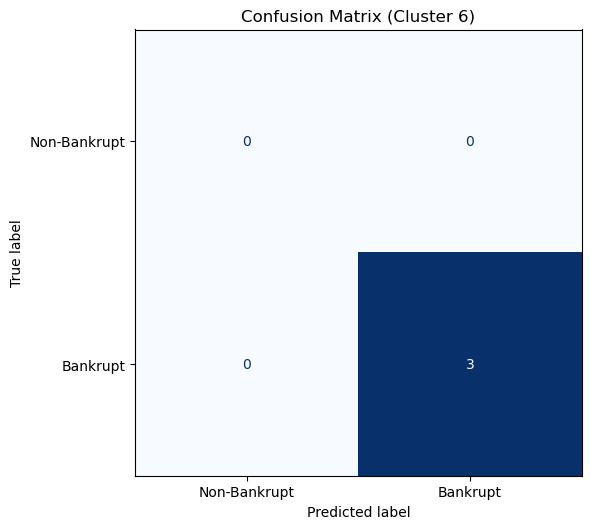

In [4]:
# Visualizations
# 1) Confusion matrix
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Bankrupt", "Bankrupt"]).plot(
    cmap="Blues", ax=plt.gca(), colorbar=False
)
plt.title(f"Confusion Matrix (Cluster {CLUSTER_ID})")
plt.grid(False)
plt.tight_layout()
plt.show()
